# Modelisation Step of Anomaly Detection Project: Machine Learning Part

### Initial model plan (with Random Forest Classifiers): 
1. Open images as grayscale and reshape all images to same size (there are different sizes for different objects) and create df
2. Train a random forest (with and without PCA dimension reduction) and hyperparameter search to detect type of object (without anomalies)
3. Check model performance for object classification on test data with anomalies (retrain with a mix of train and test data to see if performance improves)
4. Try with BalancedRandomForestClassifier (not same number of all types of objects in dataset)
5. Train a BalancedRandomForestClassifier for anomaly detection on specific objects
6. For reference try BalancedRandomForestClassifier for all objects in one go (images with and without anomalies) directly to compare performance?

> Also look into image compression/ reducing image size further or applying filters (e.g. canny) to images to reduce dimensions/ improve performance?

> Look into sampling techniques for imbalanced data.


In [60]:
# Libraries import

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import pickle as pkl


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.metrics import classification_report_imbalanced
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE


## 1. Creating dataframe for all objects in 'train' dataset

In [2]:
# Finding minimum image size
# Result: (700, 700)

'''
categories = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/MVTec").iterdir() if p.is_dir()]
print(categories)

shapes = []
for category in categories:
    train_dir = Path(f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{category}/train")
    train_files = [f for f in train_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        shapes.append(img.shape)

print(f"\nMin image size of training data is: {min(shapes)}")
'''


['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper', 'function_test']

Min image size of training data is: (700, 700)


In [3]:
# Resizing all images to be the same size as minimum and flattening to 1D array

'''
new_shape = min(shapes)

imgs_all_objs = []
labels = []

for category in categories:
    train_dir = Path(f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{category}/train")
    train_files = [f for f in train_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, dsize = new_shape, interpolation = cv2.INTER_LINEAR)
        img_resized_flat = img_resized.reshape([new_shape[0]*new_shape[1]])
        #print(img_resized_flat.shape)
        #print(img_resized_flat)
        labels.append(category)
        imgs_all_objs.append(img_resized_flat)

img_arrays = np.dstack(imgs_all_objs)
#print(img_arrays.shape)
#print(img_arrays[:2])
img_arrays = img_arrays.reshape(490000, 3629).T
'''


In [12]:
# Creating and saving dataframe with image arrays and labels (target is type of object)
# Waaaaay too big! (too many columns for my machine to handle!)

'''
df = pd.DataFrame(img_arrays)
df['target'] = labels
df.head()
df.to_pickle('./train_data.pkl')
'''


,0,1,2,3,4,5,6,7,8,9,...,489991,489992,489993,489994,489995,489996,489997,489998,489999,target
0,21,21,28,21,28,21,28,28,21,28,...,21,21,21,21,21,21,21,21,21,metal_nut
1,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,metal_nut
2,21,21,28,21,21,28,28,28,28,28,...,21,21,21,21,21,21,21,21,28,metal_nut
3,21,21,21,28,28,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,metal_nut
4,21,21,28,21,21,28,28,28,21,21,...,21,21,28,21,21,21,21,21,21,metal_nut


In [58]:
# Creating df with reduced sized images (28x28)

reduced_size = 100
categories = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/MVTec").iterdir() if p.is_dir()]

imgs_all_objs = []
labels = []

for category in categories:
    train_dir = Path(f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{category}/train")
    train_files = [f for f in train_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, dsize = (reduced_size, reduced_size), interpolation = cv2.INTER_LINEAR)
        img_resized_flat = img_resized.reshape([reduced_size*reduced_size])
        labels.append(category)
        imgs_all_objs.append(img_resized_flat)

img_arrays = np.dstack(imgs_all_objs)
img_arrays = img_arrays.reshape(reduced_size*reduced_size, len(labels)).T

df_reduced = pd.DataFrame(img_arrays)
df_reduced['target'] = labels
df_reduced.to_pickle(f'./train_data_{reduced_size}x{reduced_size}.pkl')
df_reduced.head()


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,target
0,21,28,28,28,28,28,28,21,28,28,...,21,21,28,21,21,21,28,21,21,metal_nut
1,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,28,21,21,21,metal_nut
2,28,21,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,28,metal_nut
3,28,28,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,21,metal_nut
4,21,21,21,28,28,21,21,21,21,21,...,21,21,21,21,21,21,28,21,21,metal_nut


## 2. Creating dataframe for all objects in 'test' dataset

In [28]:
# Labels are object type in one column and anomaly type in another column

categories = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/MVTec").iterdir() if p.is_dir()]

reduced_size = 100
imgs_all_objs_test = []
objs_test = []
anoms_test = []

for category in categories:
    test_dir = Path(f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{category}/test")
    anoms = [p.name for p in Path(f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{category}/test").iterdir() if p.is_dir()]
    
    for anom in anoms:
        test_im_dir = Path(os.path.join(test_dir, anom))
        test_files = [f for f in test_im_dir.rglob('*') if f.is_file()]
        #print(test_files)

        for img in test_files:
            img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
            img_resized = cv2.resize(img, dsize = (reduced_size, reduced_size), interpolation = cv2.INTER_LINEAR)
            img_resized_flat = img_resized.reshape([reduced_size*reduced_size])
            objs_test.append(category)
            anoms_test.append(anom)
            imgs_all_objs_test.append(img_resized_flat)

img_arrays_test = np.dstack(imgs_all_objs_test)
img_arrays_test = img_arrays_test.reshape(reduced_size*reduced_size, len(anoms_test)).T

df_reduced_test = pd.DataFrame(img_arrays_test)
df_reduced_test['object'] = objs_test
df_reduced_test['anomaly'] = anoms_test
df_reduced_test.to_pickle(f'./test_data_{reduced_size}x{reduced_size}.pkl')
df_reduced_test.head()


,0,1,2,3,4,5,6,7,8,9,...,9992,9993,9994,9995,9996,9997,9998,9999,object,anomaly
0,21,28,28,21,28,21,28,21,21,28,...,28,28,21,21,21,28,21,21,metal_nut,bent
1,28,28,28,21,21,21,21,28,21,28,...,21,21,21,21,28,28,28,28,metal_nut,bent
2,28,21,21,21,21,21,28,28,28,28,...,21,21,21,21,28,21,28,28,metal_nut,bent
3,28,21,28,21,21,21,28,28,28,28,...,28,28,28,28,21,28,21,21,metal_nut,bent
4,28,28,21,21,28,34,28,28,28,21,...,28,28,28,28,21,28,28,21,metal_nut,bent


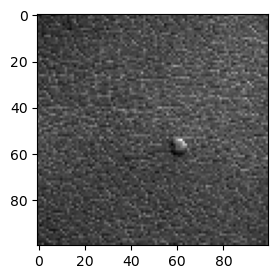

In [62]:
# Visualising sample images at various sizes and trying with filters (canny, Laplacian)

imgfile = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/leather/test/glue/002.png'
imgfile2 = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/leather/test/glue/005.png'

img_sample = cv2.imread(imgfile,cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img_sample, dsize = (100, 100), interpolation = cv2.INTER_LINEAR)

img_sample2 = cv2.imread(imgfile2,cv2.IMREAD_GRAYSCALE)
img_resized2 = cv2.resize(img_sample2, dsize = (70, 70), interpolation = cv2.INTER_LINEAR)

filter_gb = cv2.GaussianBlur(img_sample,(3,3),0)
edges = cv2.Canny(filter_gb,100,200)

laplacian = cv2.Laplacian(img_sample, ddepth = cv2.CV_64F)

plt.figure(figsize = (4,3))

plt.imshow(img_resized, cmap = 'gray');



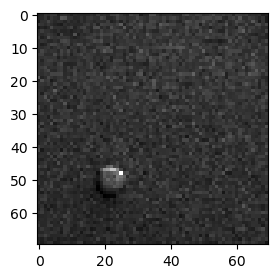

In [24]:
plt.figure(figsize = (4,3))
plt.imshow(img_resized2, cmap = 'gray');


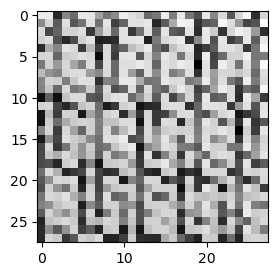

In [16]:


imgfile = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/grid/test/broken/002.png'
imgfile2 = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/grid/test/broken/005.png'

img_sample = cv2.imread(imgfile,cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img_sample, dsize = (28, 28), interpolation = cv2.INTER_LINEAR)

img_sample2 = cv2.imread(imgfile2,cv2.IMREAD_GRAYSCALE)
img_resized2 = cv2.resize(img_sample2, dsize = (70, 70), interpolation = cv2.INTER_LINEAR)

filter_gb = cv2.GaussianBlur(img_sample,(3,3),0)
edges = cv2.Canny(filter_gb,100,200)

laplacian = cv2.Laplacian(img_sample, ddepth = cv2.CV_64F)

plt.figure(figsize = (4,3))

plt.imshow(img_resized, cmap = 'gray');



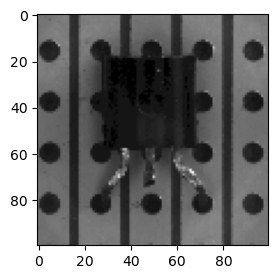

In [63]:
imgfile = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/transistor/test/cut_lead/002.png'

img_sample = cv2.imread(imgfile,cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img_sample, dsize = (100, 100), interpolation = cv2.INTER_LINEAR)

filter_gb = cv2.GaussianBlur(img_sample,(3,3),0)
edges = cv2.Canny(filter_gb,100,200)

laplacian = cv2.Laplacian(img_sample, ddepth = cv2.CV_64F)

plt.figure(figsize = (4,3))

plt.imshow(img_resized, cmap = 'gray');

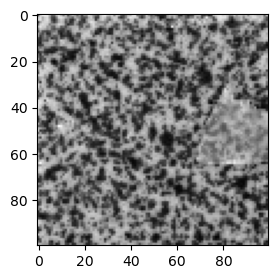

In [51]:
imgfile = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/tile/test/glue_strip/002.png'

img_sample = cv2.imread(imgfile,cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img_sample, dsize = (100, 100), interpolation = cv2.INTER_LINEAR)

filter_gb = cv2.GaussianBlur(img_sample,(3,3),0)
edges = cv2.Canny(filter_gb,100,200)

laplacian = cv2.Laplacian(img_sample, ddepth = cv2.CV_64F)

plt.figure(figsize = (4,3))

plt.imshow(img_resized, cmap = 'gray');

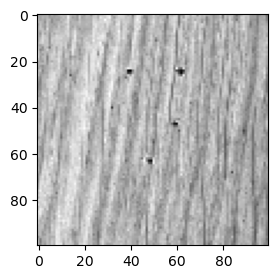

In [57]:
imgfile = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec/wood/test/hole/002.png'

img_sample = cv2.imread(imgfile,cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img_sample, dsize = (100, 100), interpolation = cv2.INTER_LINEAR)

filter_gb = cv2.GaussianBlur(img_sample,(3,3),0)
edges = cv2.Canny(filter_gb,100,200)

laplacian = cv2.Laplacian(img_sample, ddepth = cv2.CV_64F)

plt.figure(figsize = (4,3))

plt.imshow(img_resized, cmap = 'gray');


## 3. Training Random Forest Classifier for object type detection (without anomalies)

In [4]:
# Load data to use for model training

df_from_pickle = pd.read_pickle('./train_data_28x28.pkl')
df = df_from_pickle
df.head()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,21,61,70,21,21,28,102,68,21,147,...,86,30,69,59,255,48,62,75,59,metal_nut
1,28,56,74,21,21,21,87,70,21,124,...,50,41,72,70,255,64,50,70,34,metal_nut
2,21,64,59,21,21,21,95,59,21,132,...,57,52,64,80,255,66,55,83,64,metal_nut
3,21,72,107,21,21,21,95,96,21,72,...,70,54,82,66,255,51,56,255,29,metal_nut
4,28,80,39,21,21,21,53,100,21,61,...,45,60,255,62,46,76,32,255,36,metal_nut


In [5]:
# Training a basic random forest classifier (without hyperparam optimisation or PCA)

categories = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/MVTec").iterdir() if p.is_dir()]

target = df['target']
target_num = target.replace(to_replace=categories, value=list(np.arange(len(categories))))
features = df.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)


/tmp/ipykernel_856/1595555209.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = target.replace(to_replace=categories, value=list(np.arange(len(categories))))


In [6]:
clf = RandomForestClassifier(n_jobs=-1)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)


0.9944903581267218

In [7]:
test_pred = clf.predict(X_test)
print(classification_report(y_test, test_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        77
           2       1.00      1.00      1.00        41
           3       0.98      1.00      0.99        40
           4       1.00      0.98      0.99        49
           5       1.00      1.00      1.00        39
           6       1.00      1.00      1.00        51
           7       0.98      1.00      0.99        49
           8       1.00      0.98      0.99        44
           9       1.00      1.00      1.00        72
          10       1.00      1.00      1.00        55
          11       0.98      1.00      0.99        54
          12       1.00      0.85      0.92        13
          13       0.98      1.00      0.99        41
          14       1.00      1.00      1.00        49

    accuracy                           0.99       726
   macro avg       0.99      0.99      0.99       726
weighted avg       0.99   

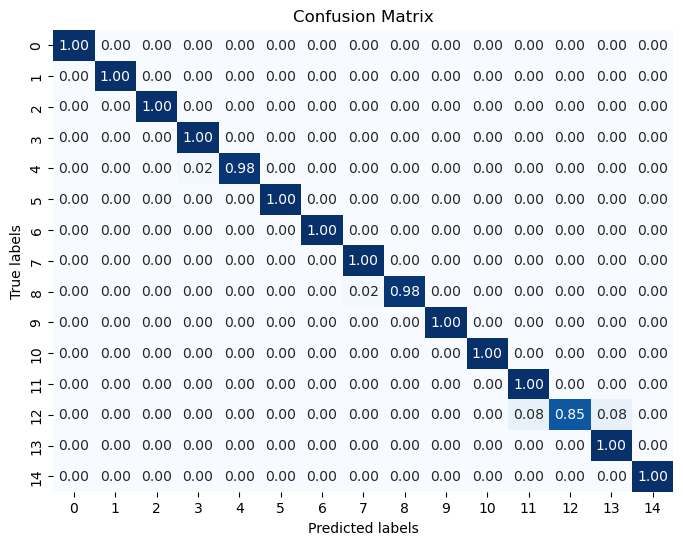

toothbrush


In [9]:
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()
print(categories[12])


## 4. Comparing model performance on test data (with anomalies)

In [10]:
# Load test data

df_from_pickle = pd.read_pickle('./test_data_28x28.pkl')
df_test = df_from_pickle
df_test.head()


,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,object,anomaly
0,21,28,28,21,21,21,21,21,28,21,...,21,21,28,28,21,21,28,28,metal_nut,bent
1,28,28,28,28,28,28,28,21,21,21,...,21,21,21,21,21,28,21,21,metal_nut,bent
2,21,21,28,21,21,28,21,21,21,21,...,21,28,28,21,28,21,28,28,metal_nut,bent
3,28,21,28,21,21,28,28,21,21,28,...,28,21,28,21,21,21,28,28,metal_nut,bent
4,21,28,21,21,21,28,28,28,21,21,...,28,21,28,28,21,21,21,28,metal_nut,bent


In [11]:
# Checking performance of model trained on good only train data on test data (mix of good and various anomalies)

target_test = df_test['object']
target_test_num = target_test.replace(to_replace=categories, value=list(np.arange(len(categories))) )
features_test = df_test.drop(['object', 'anomaly'], axis=1)

#display(features_test.head())
#display(target_test_num.head())


/tmp/ipykernel_856/1172460051.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_test_num = target_test.replace(to_replace=categories, value=list(np.arange(len(categories))) )


In [13]:
display(clf.score(features_test, target_test_num))
test_pred = clf.predict(features_test)
print(classification_report(target_test_num, test_pred))


0.021449275362318842

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.02      0.03      0.02       160
           2       0.00      0.00      0.00       117
           3       0.00      0.00      0.00       100
           4       0.00      0.00      0.00        83
           5       0.08      0.11      0.10       150
           6       0.00      0.00      0.00       132
           7       0.03      0.09      0.05       117
           8       0.02      0.01      0.02        78
           9       0.00      0.01      0.00       110
          10       0.00      0.00      0.00       124
          11       0.00      0.00      0.00       167
          12       0.00      0.00      0.00        42
          13       0.14      0.04      0.06        79
          14       0.00      0.00      0.00       151

    accuracy                           0.02      1725
   macro avg       0.02      0.02      0.02      1725
weighted avg       0.02   

/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

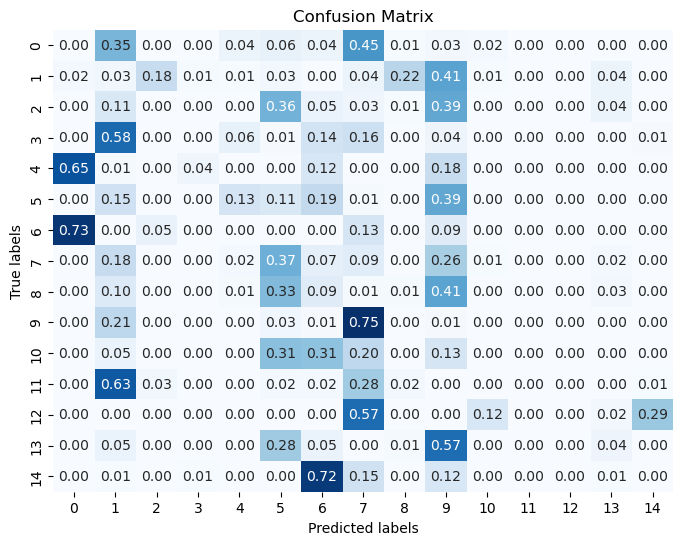

In [14]:
cnf_matrix = confusion_matrix(target_test_num, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


In [102]:
print(categories)
print('Train: 2, 7, 8')
print('Test: 2, 7, 8, 10')
print(categories[2], categories[7], categories[8], categories[10])

['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper']
Train: 2, 7, 8
Test: 2, 7, 8, 10
tile carpet grid leather


In [48]:
# Trialling separate models for 'texture' or 'object' types

textures = ['tile', 'carpet', 'wood', 'grid', 'leather']
objects = [item for item in categories if item not in textures]

df_train_texture = df[df['target'].isin(textures)]
df_test_texture = df_test[df_test['object'].isin(textures)]


In [49]:
# Train for textures only

target = df_train_texture['target']
target_num = target.replace(to_replace=categories, value=list(np.arange(len(categories))))
features = df_train_texture.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_jobs=-1, max_depth=5, n_estimators=100, max_features='log2', max_leaf_nodes=10)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)


/tmp/ipykernel_957/2590574461.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = target.replace(to_replace=categories, value=list(np.arange(len(categories))))


0.9921259842519685

In [51]:
target_num_test = df_test_texture['object'].replace(to_replace=categories, value=list(np.arange(len(categories))))
features_test = df_test_texture.drop(['object', 'anomaly'], axis=1)

clf.score(features_test, target_num_test)


/tmp/ipykernel_957/1532434009.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num_test = df_test_texture['object'].replace(to_replace=categories, value=list(np.arange(len(categories))))


0.20776699029126214

In [66]:
# Try training with train and test mixed

df_train = pd.read_pickle('./train_data_100x100.pkl')
df_test = pd.read_pickle('./test_data_100x100.pkl')
df_test.drop('anomaly', axis=1, inplace=True)
df_test.rename({'object': 'target'}, axis=1, inplace=True)

#display(df_train.head())
#display(df_test.head())
df_train_test = pd.concat([df_train, df_test], axis=0)
display(df_train_test.head())
display(df_train_test.shape)


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,target
0,21,28,28,28,28,28,28,21,28,28,...,21,21,28,21,21,21,28,21,21,metal_nut
1,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,28,21,21,21,metal_nut
2,28,21,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,28,metal_nut
3,28,28,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,21,metal_nut
4,21,21,21,28,28,21,21,21,21,21,...,21,21,21,21,21,21,28,21,21,metal_nut


(5354, 10001)

In [67]:
target_num = df_train_test['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))
features = df_train_test.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='log2', max_leaf_nodes=30)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)


/tmp/ipykernel_856/831011971.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = df_train_test['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))


0.9551820728291317

In [68]:
test_pred = clf.predict(X_test)
print(classification_report(y_test, test_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00       101
           2       0.67      0.85      0.75        66
           3       1.00      0.98      0.99        59
           4       1.00      1.00      1.00        63
           5       1.00      1.00      1.00        74
           6       1.00      1.00      1.00        81
           7       0.80      1.00      0.89        70
           8       0.88      0.38      0.53        60
           9       1.00      1.00      1.00       102
          10       1.00      1.00      1.00        78
          11       1.00      1.00      1.00        90
          12       1.00      1.00      1.00        22
          13       1.00      1.00      1.00        56
          14       1.00      1.00      1.00        81

    accuracy                           0.96      1071
   macro avg       0.96      0.95      0.94      1071
weighted avg       0.96   

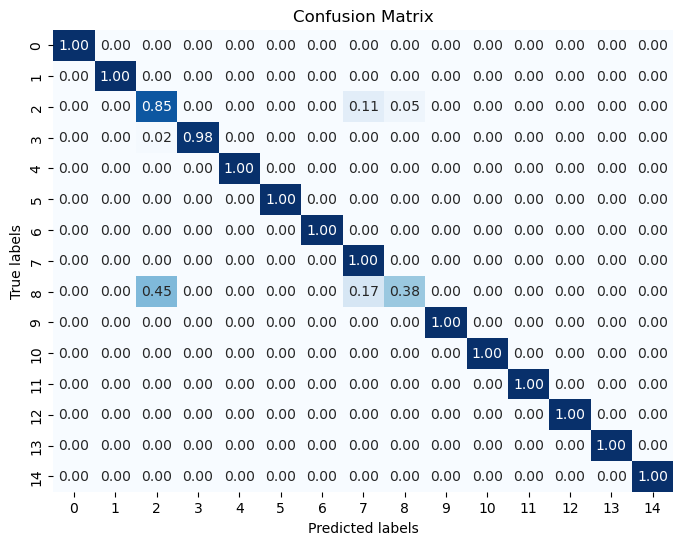

Worst performance for least represented object type in dataset (12, toothbrush) and also for texture-types (7+8, carpet+grid)
TODO: 
 1. Try separate models for object and texture types 
2. Try with BalancedRandomForest and random undersampling to improve for toothbrush


In [69]:
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()
print('Worst performance for least represented object type in dataset (12, toothbrush) and also for texture-types (7+8, carpet+grid)')
print('TODO: \n 1. Try separate models for object and texture types \n2. Try with BalancedRandomForest and random undersampling to improve for toothbrush')


In [70]:
# Checking performance with a holdout set from the test set (not including in training)

df_test_red, test_holdout, test_y_train, test_y_holdout = train_test_split(df_test, df_test['target'], test_size=0.2, random_state=123)
df_train_test_red = pd.concat([df_train, df_test_red], axis=0)
print(df_train_test_red.shape)
print(test_holdout.shape)


(5009, 10001)
(345, 10001)


In [71]:
features = df_train_test_red.drop('target', axis=1)
target_num = df_train_test_red['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))

X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='log2', max_leaf_nodes=30)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)


/tmp/ipykernel_856/2830370073.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = df_train_test_red['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))


0.969061876247505

In [72]:
holdout_target_num = test_y_holdout.replace(to_replace=categories, value=list(np.arange(len(categories))))
holdout_X = test_holdout.drop('target', axis=1)

clf.score(holdout_X, holdout_target_num)


/tmp/ipykernel_856/2465552138.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  holdout_target_num = test_y_holdout.replace(to_replace=categories, value=list(np.arange(len(categories))))


0.9449275362318841

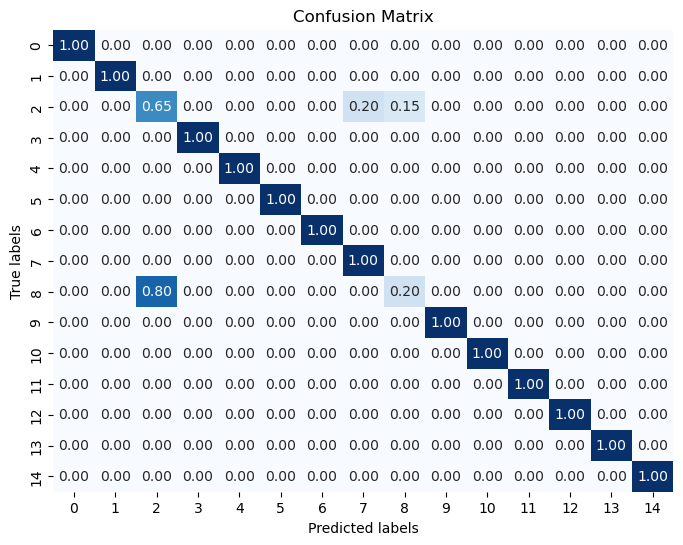

Clearly worse performance for texture types 2, 7, 8, 13
tile carpet grid wood leather


In [73]:
test_pred = clf.predict(holdout_X)
cnf_matrix = confusion_matrix(holdout_target_num, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()

print('Clearly worse performance for texture types 2, 7, 8, 13')
print(categories[2], categories[7], categories[8], categories[13], categories[10])

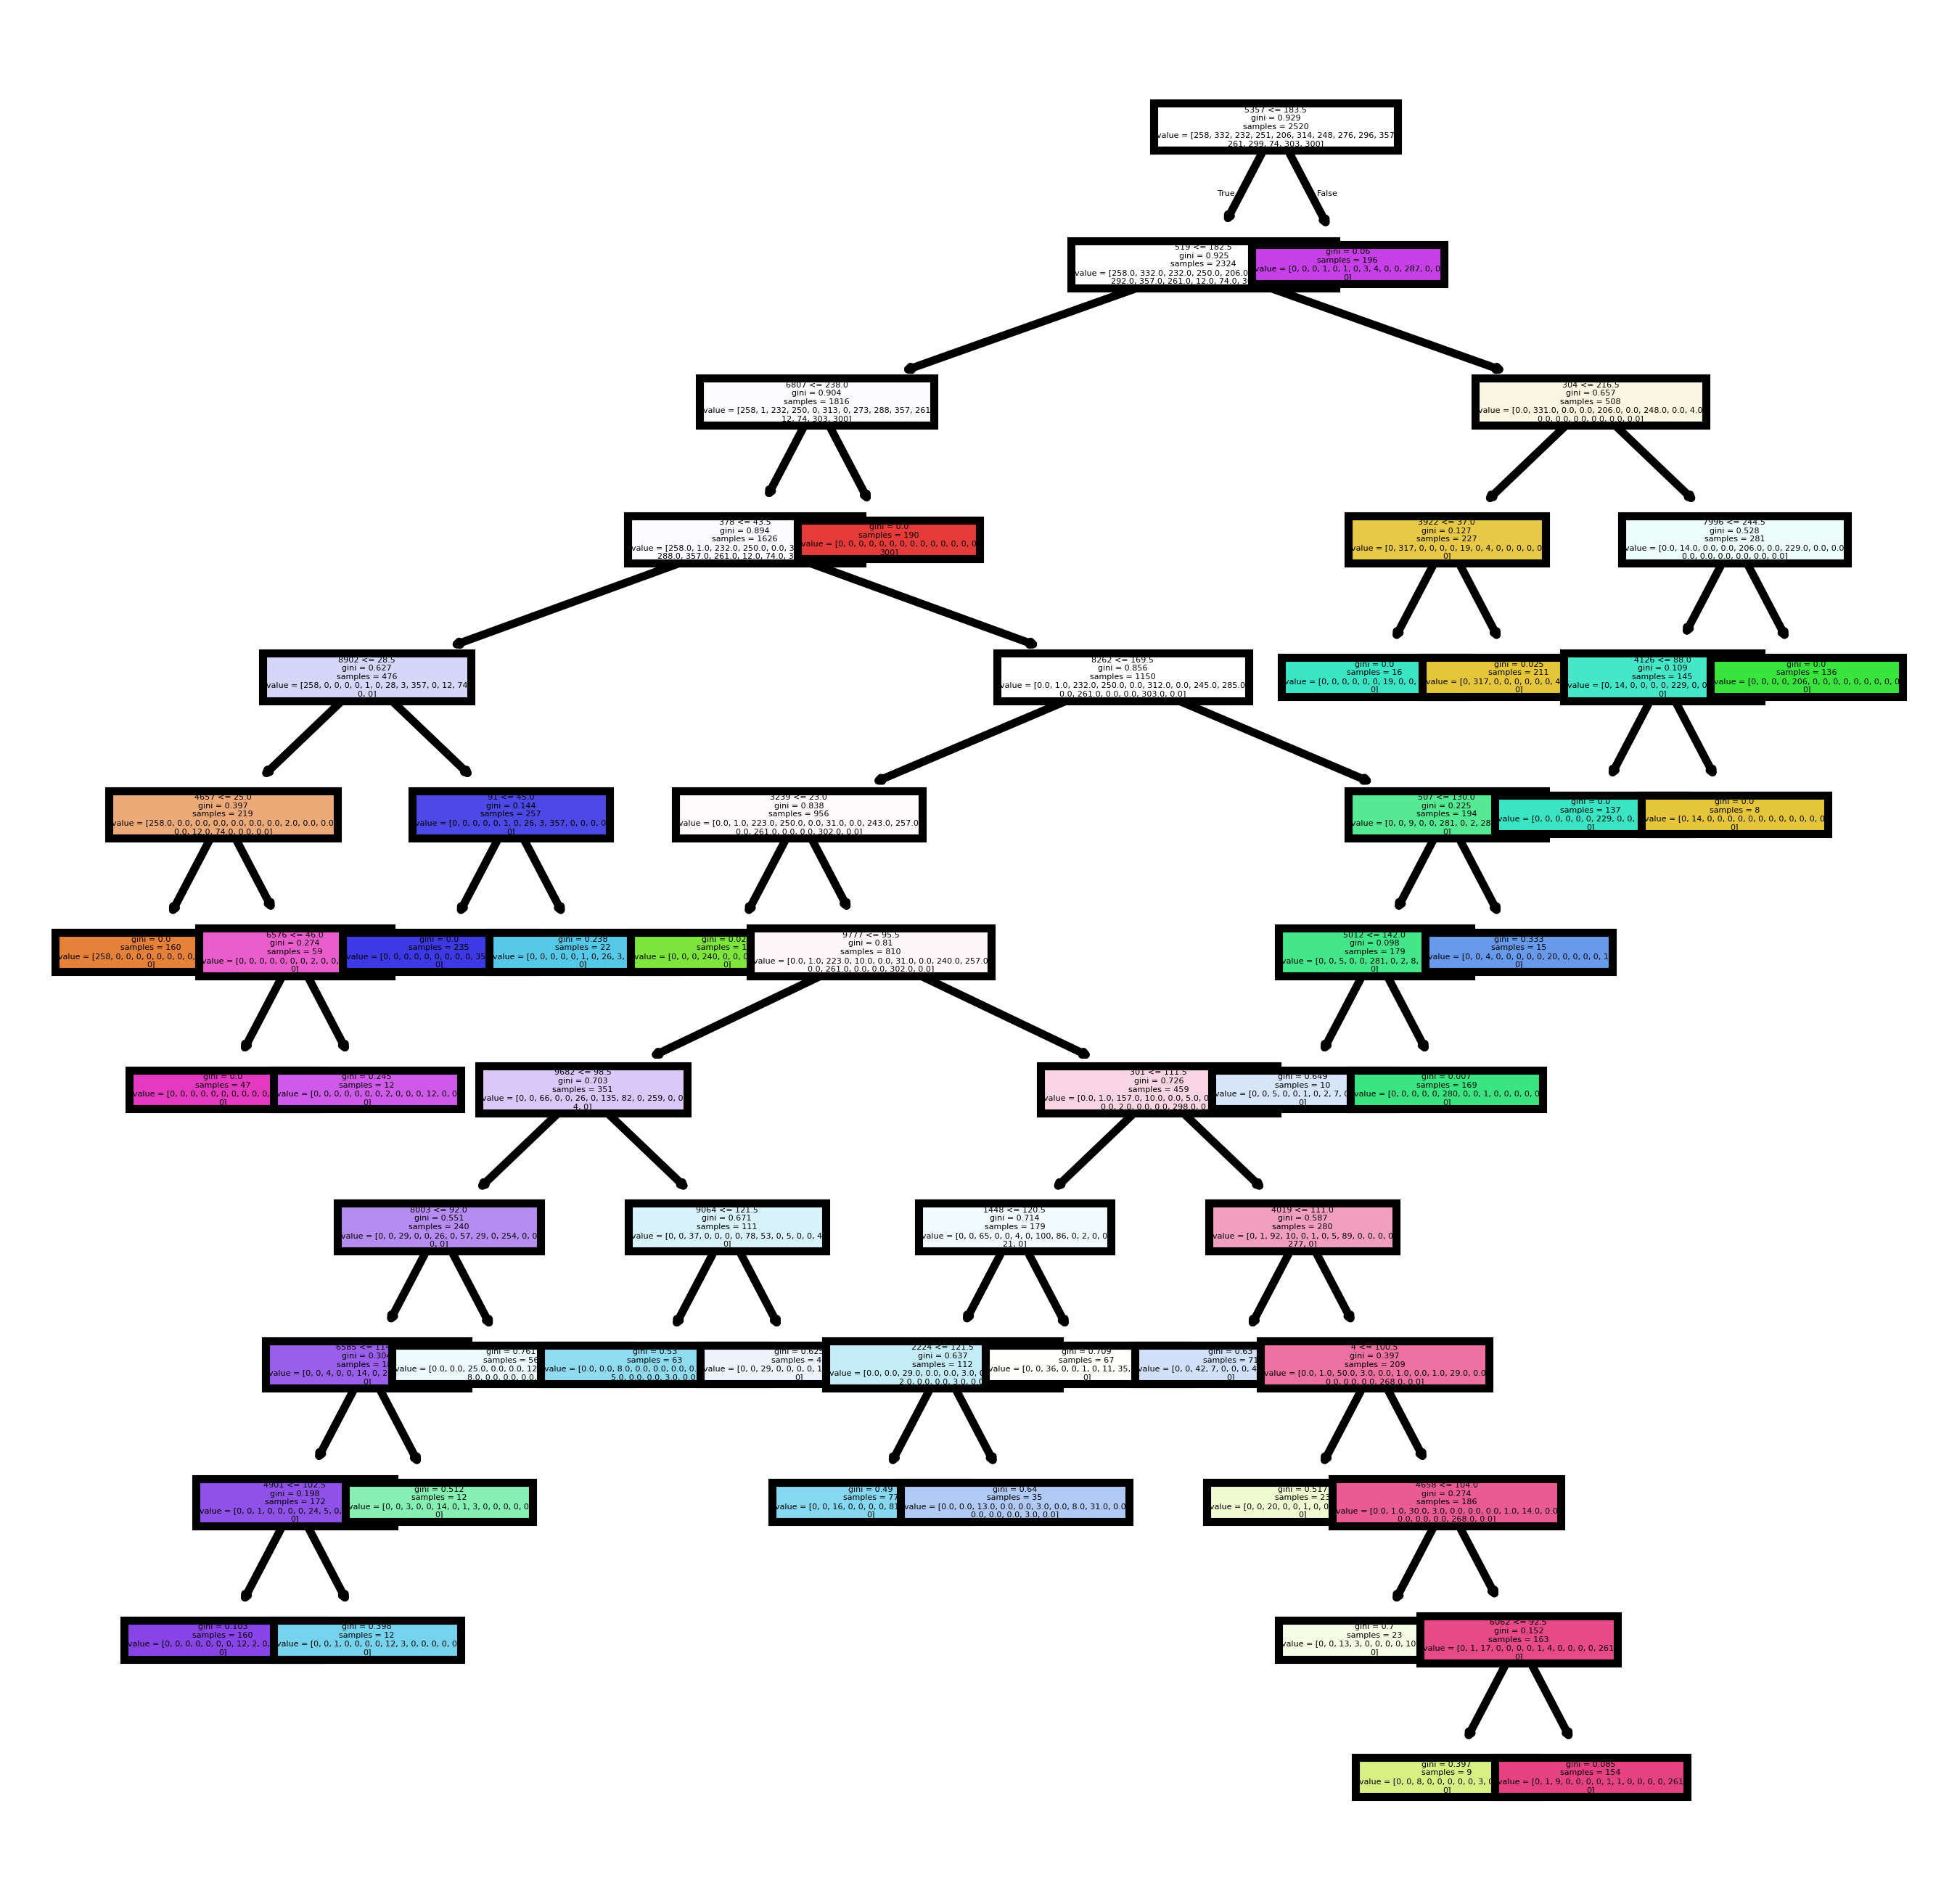

In [75]:
from sklearn import tree

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(clf.estimators_[0],
               feature_names = features.columns, 
               filled = True);

fig.savefig('multi-class_tree.png')




In [36]:
# Trying training with test holdout for texture types only

textures = ['tile', 'carpet', 'wood', 'grid', 'leather']
objects = [item for item in categories if item not in textures]

df_train_texture = df_train_test_red[df_train_test_red['target'].isin(textures)]
df_train_obj = df_train_test_red[df_train_test_red['target'].isin(objects)]

features = df_train_texture.drop('target', axis=1)
target_num = df_train_texture['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))

X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='log2', max_leaf_nodes=30)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)



/tmp/ipykernel_856/3069322703.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = df_train_texture['target'].replace(to_replace=categories, value=list(np.arange(len(categories))))


0.8958333333333334

In [39]:

holdout_texture = test_y_holdout[test_y_holdout.isin(textures)]
holdout_target_num = holdout_texture.replace(to_replace=categories, value=list(np.arange(len(categories))))
holdout_X = test_holdout[test_holdout['target'].isin(textures)].drop('target', axis=1)

clf.score(holdout_X, holdout_target_num)

/tmp/ipykernel_856/1089415822.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  holdout_target_num = holdout_texture.replace(to_replace=categories, value=list(np.arange(len(categories))))


0.8571428571428571

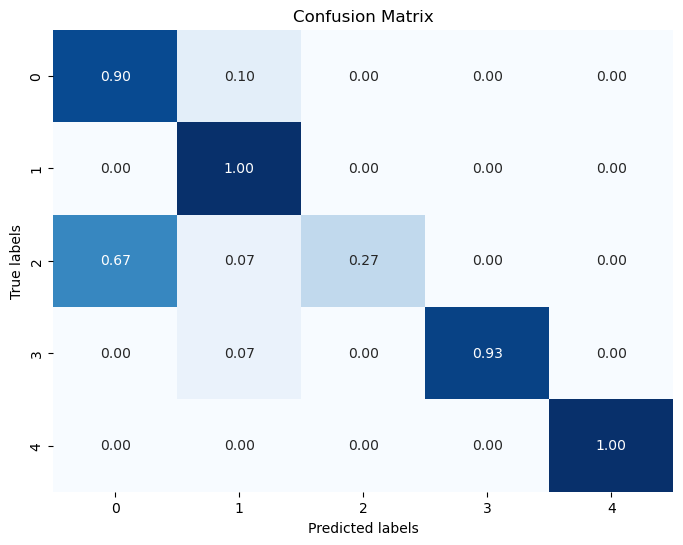

In [40]:
test_pred = clf.predict(holdout_X)
cnf_matrix = confusion_matrix(holdout_target_num, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


0.75


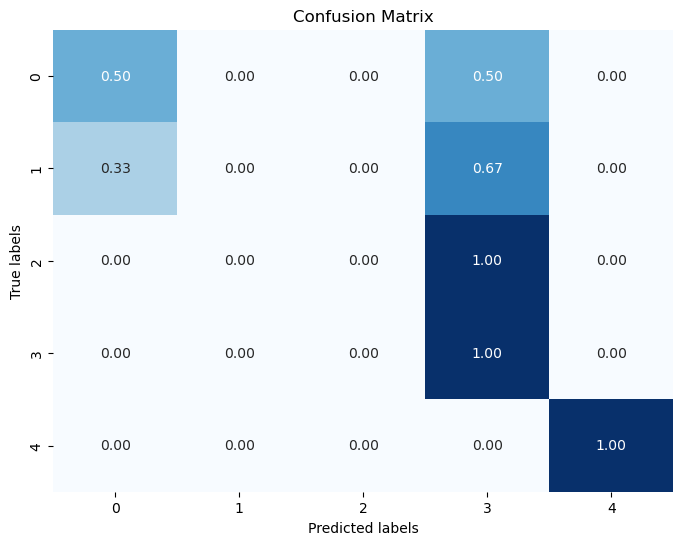

In [127]:
# Checking if possible to train for anomaly type for specific objects

df_test = pd.read_pickle('./test_data_28x28.pkl')
df_test_transistor = df_test[df_test['object']=='transistor']
df_test_transistor = df_test_transistor.drop('object', axis=1)

features = df_test_transistor.drop('anomaly', axis=1)
target = df_test_transistor['anomaly']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=150, max_features='sqrt', max_leaf_nodes=30)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

test_pred = clf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


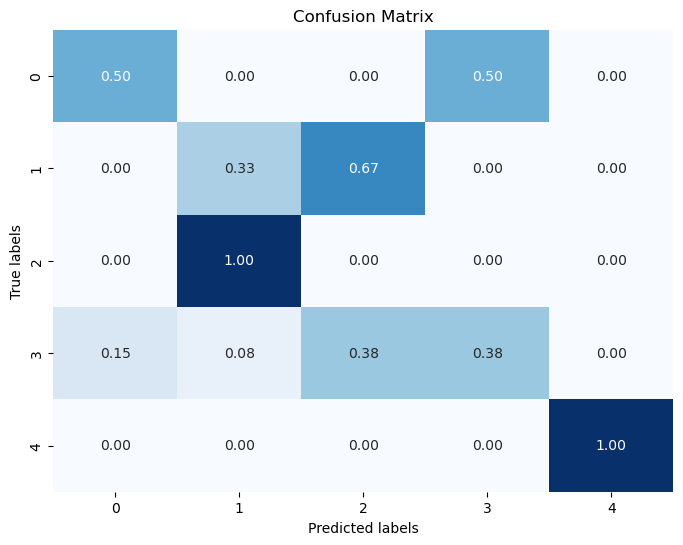

In [129]:
from imblearn.ensemble import BalancedRandomForestClassifier

bclf = BalancedRandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=100, max_features='log2', max_leaf_nodes=20)
bclf.fit(X_train, y_train) 
bclf.score(X_test, y_test)

test_pred = bclf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


0.65


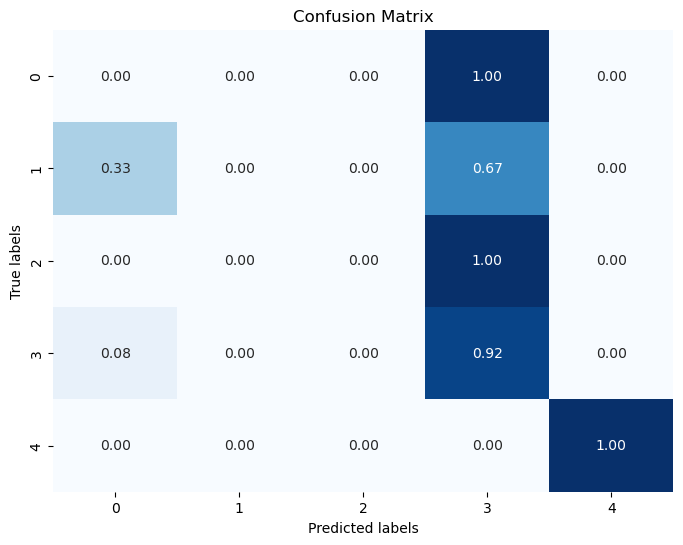

In [75]:
# Trying with bigger images + PCA

df_test = pd.read_pickle('./test_data_100x100.pkl')

df_test_transistor = df_test[df_test['object']=='transistor']
df_test_transistor = df_test_transistor.drop('object', axis=1)

features = df_test_transistor.drop('anomaly', axis=1)
target = df_test_transistor['anomaly']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=150, max_features='sqrt', max_leaf_nodes=30)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

test_pred = clf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()



/tmp/ipykernel_571/562258718.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_transistor['label'] = df_test_transistor['anomaly'].replace(to_replace=anoms, value=list(np.arange(len(anoms))))


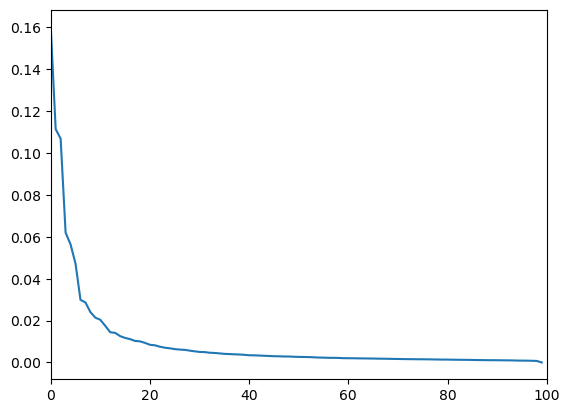

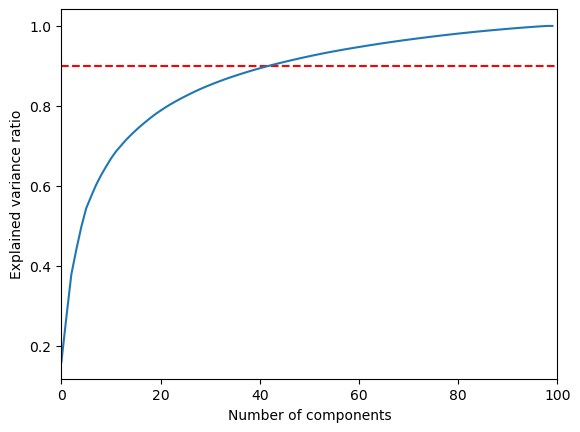

In [76]:
from sklearn.decomposition import PCA

df_test_transistor = df_test[df_test['object']=='transistor']
df_test_transistor = df_test_transistor.drop('object', axis=1)
anoms = list(df_test_transistor['anomaly'].unique())
df_test_transistor['label'] = df_test_transistor['anomaly'].replace(to_replace=anoms, value=list(np.arange(len(anoms))))
df_test_transistor = df_test_transistor.drop('anomaly', axis=1)

target = df_test_transistor['label']
data = df_test_transistor.drop('label', axis=1)


pca = PCA()
pca.fit(data)

plt.figure()
plt.xlim(0,100)
plt.plot(pca.explained_variance_ratio_);

plt.figure()
plt.xlim(0,100)
plt.xlabel('Number of components')
plt.ylabel('Explained variance ratio')
plt.axhline(y = 0.9, color ='r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());



In [149]:
pca = PCA(n_components = 0.9)
pca.fit(data)
print("Number of components retained:", pca.n_components_)


Number of components retained: 40


In [166]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf = BalancedRandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
clf.fit(X_train_pca, y_train)
clf.score(X_test_pca, y_test)


0.55

/tmp/ipykernel_571/2808891927.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = df_test['object'].replace(to_replace=categories, value=list(np.arange(len(categories))) )


0.9449275362318841


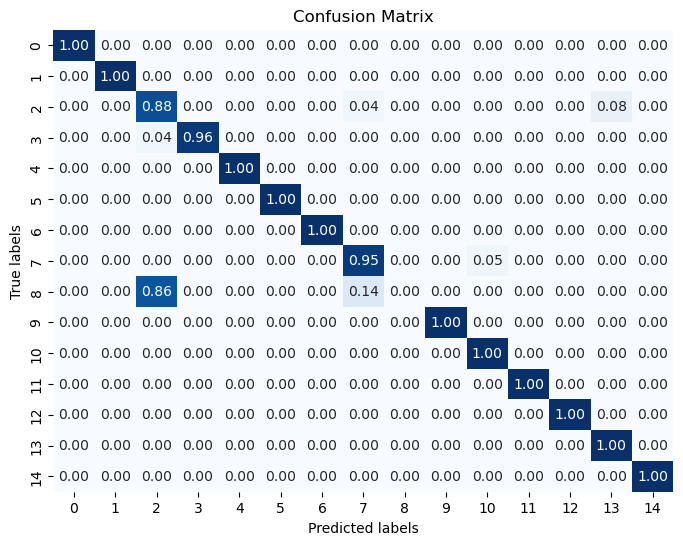

tile grid


In [40]:
# Trying image classification with bigger images + PCA

df_test = pd.read_pickle('./test_data_100x100.pkl')

target_num = df_test['object'].replace(to_replace=categories, value=list(np.arange(len(categories))) )
features = df_test.drop(['object', 'anomaly'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=150, max_features='sqrt', max_leaf_nodes=30)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

test_pred = clf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()

print(categories[2], categories[8])

Number of components retained: 18
0.9072463768115943


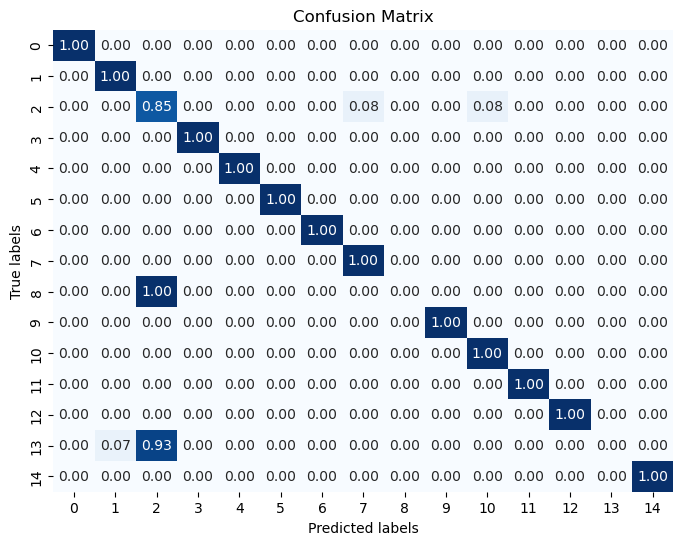

tile grid


In [41]:
# With PCA 

pca = PCA(n_components = 0.9)
pca.fit(features)
print("Number of components retained:", pca.n_components_)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
clf.fit(X_train_pca, y_train)
print(clf.score(X_test_pca, y_test))

test_pred = clf.predict(X_test_pca)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()

print(categories[2], categories[8])

/tmp/ipykernel_571/2198708753.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_num = df_texture['object'].replace(to_replace=categories, value=list(np.arange(len(categories))) )


0.8737864077669902


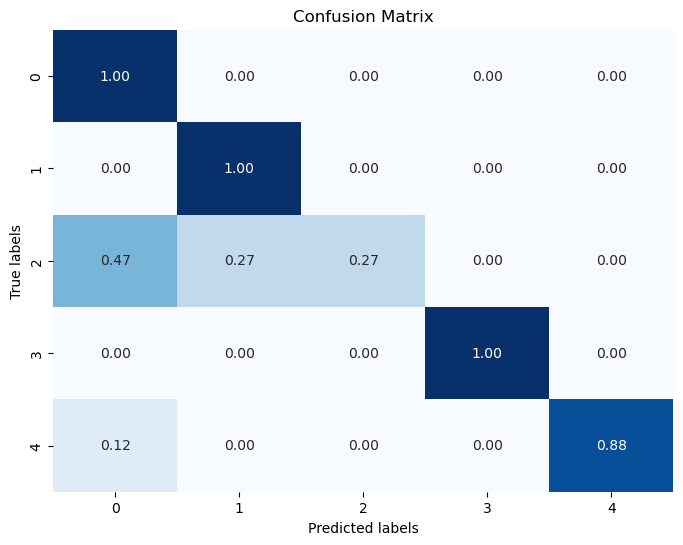

In [43]:
# Trying image classification with bigger images (texture type only)

df_test = pd.read_pickle('./test_data_100x100.pkl')

textures = ['tile', 'carpet', 'wood', 'grid', 'leather']
objects = [item for item in categories if item not in textures]

df_texture = df_test[df_test['object'].isin(textures)]
df_object = df_test[df_test['object'].isin(objects)]


target_num = df_texture['object'].replace(to_replace=categories, value=list(np.arange(len(categories))) )
features = df_texture.drop(['object', 'anomaly'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=150, max_features='sqrt', max_leaf_nodes=30)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

test_pred = clf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()

0.8155339805825242


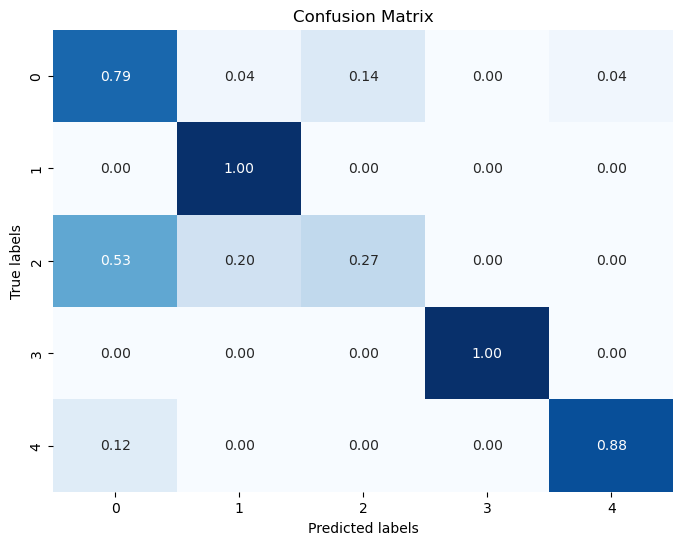

In [45]:
X_train, X_test, y_train, y_test = train_test_split(features, target_num, test_size=0.2, random_state=42)
clf = BalancedRandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=150, max_features='sqrt', max_leaf_nodes=30)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

test_pred = clf.predict(X_test)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


Number of components retained: 268
0.883495145631068


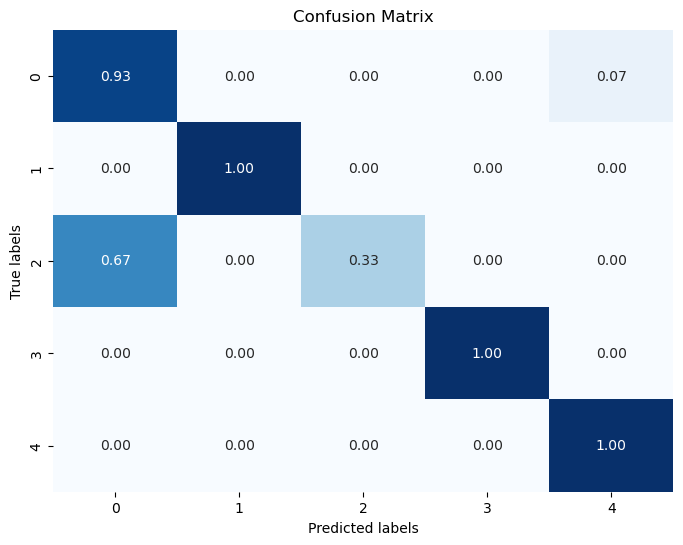

tile grid


In [52]:
# With PCA 

pca = PCA(n_components = 0.9)
pca.fit(features)
print("Number of components retained:", pca.n_components_)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
clf.fit(X_train_pca, y_train)
print(clf.score(X_test_pca, y_test))

test_pred = clf.predict(X_test_pca)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


0.8058252427184466


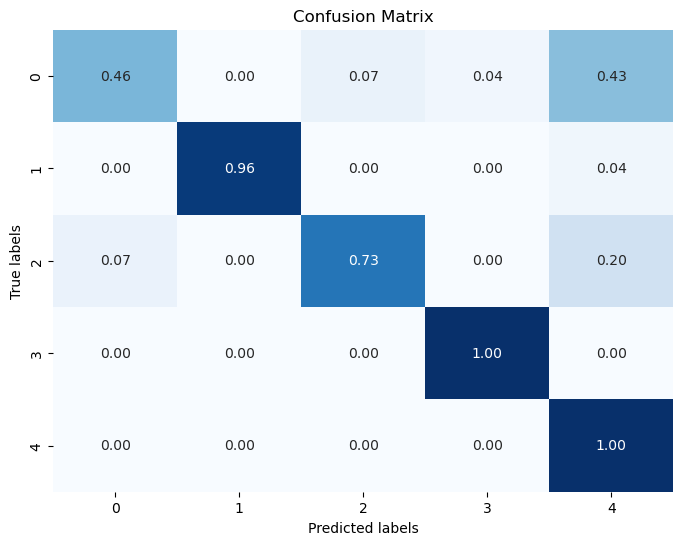

tile wood


In [54]:
clf = BalancedRandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
clf.fit(X_train_pca, y_train)
print(clf.score(X_test_pca, y_test))

test_pred = clf.predict(X_test_pca)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')

plt.figure(figsize=(8, 6))

plt.title("Confusion Matrix")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()

print(textures[0], textures[2])

## Findings so far:

1. Object classification on train dataset (no anomalies) surprisingly good performance (even with small image size 28x28 and no hyperparam optimisation or PCA)
2. Object classification model trained on train set (no anomalies) did not generalise AT ALL to test set (with a mix of normal and anomalous images)
3. When mixing train and test sets and using hyper param optimisation, PCA, BalancedRandomForest and larger images (up to 100x100) performance improved but classification of certain object types (in particular texture-like such as tile) was unsuccessful, even after trying to train a separate model for texture-like only (Note: texture-like are not the least well represented in the dataset either)
4. So far multi-class anomaly detection per object (model trained on test dataset only with object subset) has not been successful
5. Applying filters, e.g. canny, does not appear to help highlight features in images for model training
6. A model trained for normal vs. anomaly binary classification for a specific object detects well 'good' class but poorly the anomaly class
7. Try undersampling/ oversampling techniques
8. Anomaly detection algos (isolation forest, one class SVM, KNN) all very poor recall for anomaly class (for all objects together, slightly better for objects separately but still poor)
9. Best model of investigation (to confirm): Multi-class object classification with random forest and mix of train and test data with various optimisations (bigger images, ...) + binary anomaly detection on single object type with undersampling (but still limited, some objects like texture-type e.g. tile poorly classified and generally poorer recall on anomaly class)
10. TODO: For best model, do hyperparam search + cross validation (need for cv due to variability in performance on test set depending on train test split)
11. TODO: Next week try deep learning anomaly detection method? (last notebook of anomaly detection module)


In [55]:
# Binary anomaly vs not anomaly for transistor + stratify param for class balancing in train test split

import warnings

df_test = pd.read_pickle('./test_data_100x100.pkl')
df_test_transistor = df_test[df_test['object']=='transistor']
df_test_transistor = df_test_transistor.drop('object', axis=1)

df_test_transistor['target'] = np.where(df_test_transistor['anomaly']=='good', 0, 1)
target = df_test_transistor['target']
features = df_test_transistor.drop(['anomaly', 'target'], axis=1)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target, shuffle=True)
    clf = RandomForestClassifier(n_jobs=-1, max_depth=10, n_estimators=200, max_features='sqrt', max_leaf_nodes=10)
    clf.fit(X_train, y_train)
    print(f'Score: {clf.score(X_test, y_test)}\n')
    
    y_pred = clf.predict(X_test)
    print(classification_report_imbalanced(y_test, y_pred))
    cnf_matrix = pd.crosstab(y_test, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)


Score: 0.85

                   pre       rec       spe        f1       geo       iba       sup

          0       0.80      1.00      0.62      0.89      0.79      0.65        12
          1       1.00      0.62      1.00      0.77      0.79      0.60         8

avg / total       0.88      0.85      0.78      0.84      0.79      0.63        20



Predicted Class,0,1
True Class,,
0,12,0
1,3,5


In [49]:
# Try with PCA for 'Binary anomaly vs not anomaly for transistor'

pca = PCA(n_components = 0.9)
pca.fit(features)
print("Number of components retained:", pca.n_components_)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    #clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
    clf.fit(X_train_pca, y_train)
    print(clf.score(X_test_pca, y_test))

    y_pred = clf.predict(X_test_pca)
    print(classification_report_imbalanced(y_test, y_pred))
    cnf_matrix = pd.crosstab(y_test, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)


Number of components retained: 43
0.8
                   pre       rec       spe        f1       geo       iba       sup

          0       0.75      1.00      0.50      0.86      0.71      0.53        12
          1       1.00      0.50      1.00      0.67      0.71      0.48         8

avg / total       0.85      0.80      0.70      0.78      0.71      0.51        20



Predicted Class,0,1
True Class,,
0,12,0
1,4,4


In [59]:
# Try with undersampling majority class

display(df_test_transistor['target'].value_counts())

rus = RandomUnderSampler()
X_ru, y_ru = rus.fit_resample(X_train, y_train)

display(y_ru.value_counts())

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    #clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
    clf.fit(X_ru, y_ru)
    print(clf.score(X_test, y_test))

    y_pred = clf.predict(X_test)
    print(classification_report_imbalanced(y_test, y_pred))
    cnf_matrix = pd.crosstab(y_test, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)



target
0    60
1    40
Name: count, dtype: int64

target
0    32
1    32
Name: count, dtype: int64

0.9
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      1.00      0.75      0.92      0.87      0.77        12
          1       1.00      0.75      1.00      0.86      0.87      0.73         8

avg / total       0.91      0.90      0.85      0.90      0.87      0.75        20



Predicted Class,0,1
True Class,,
0,12,0
1,2,6


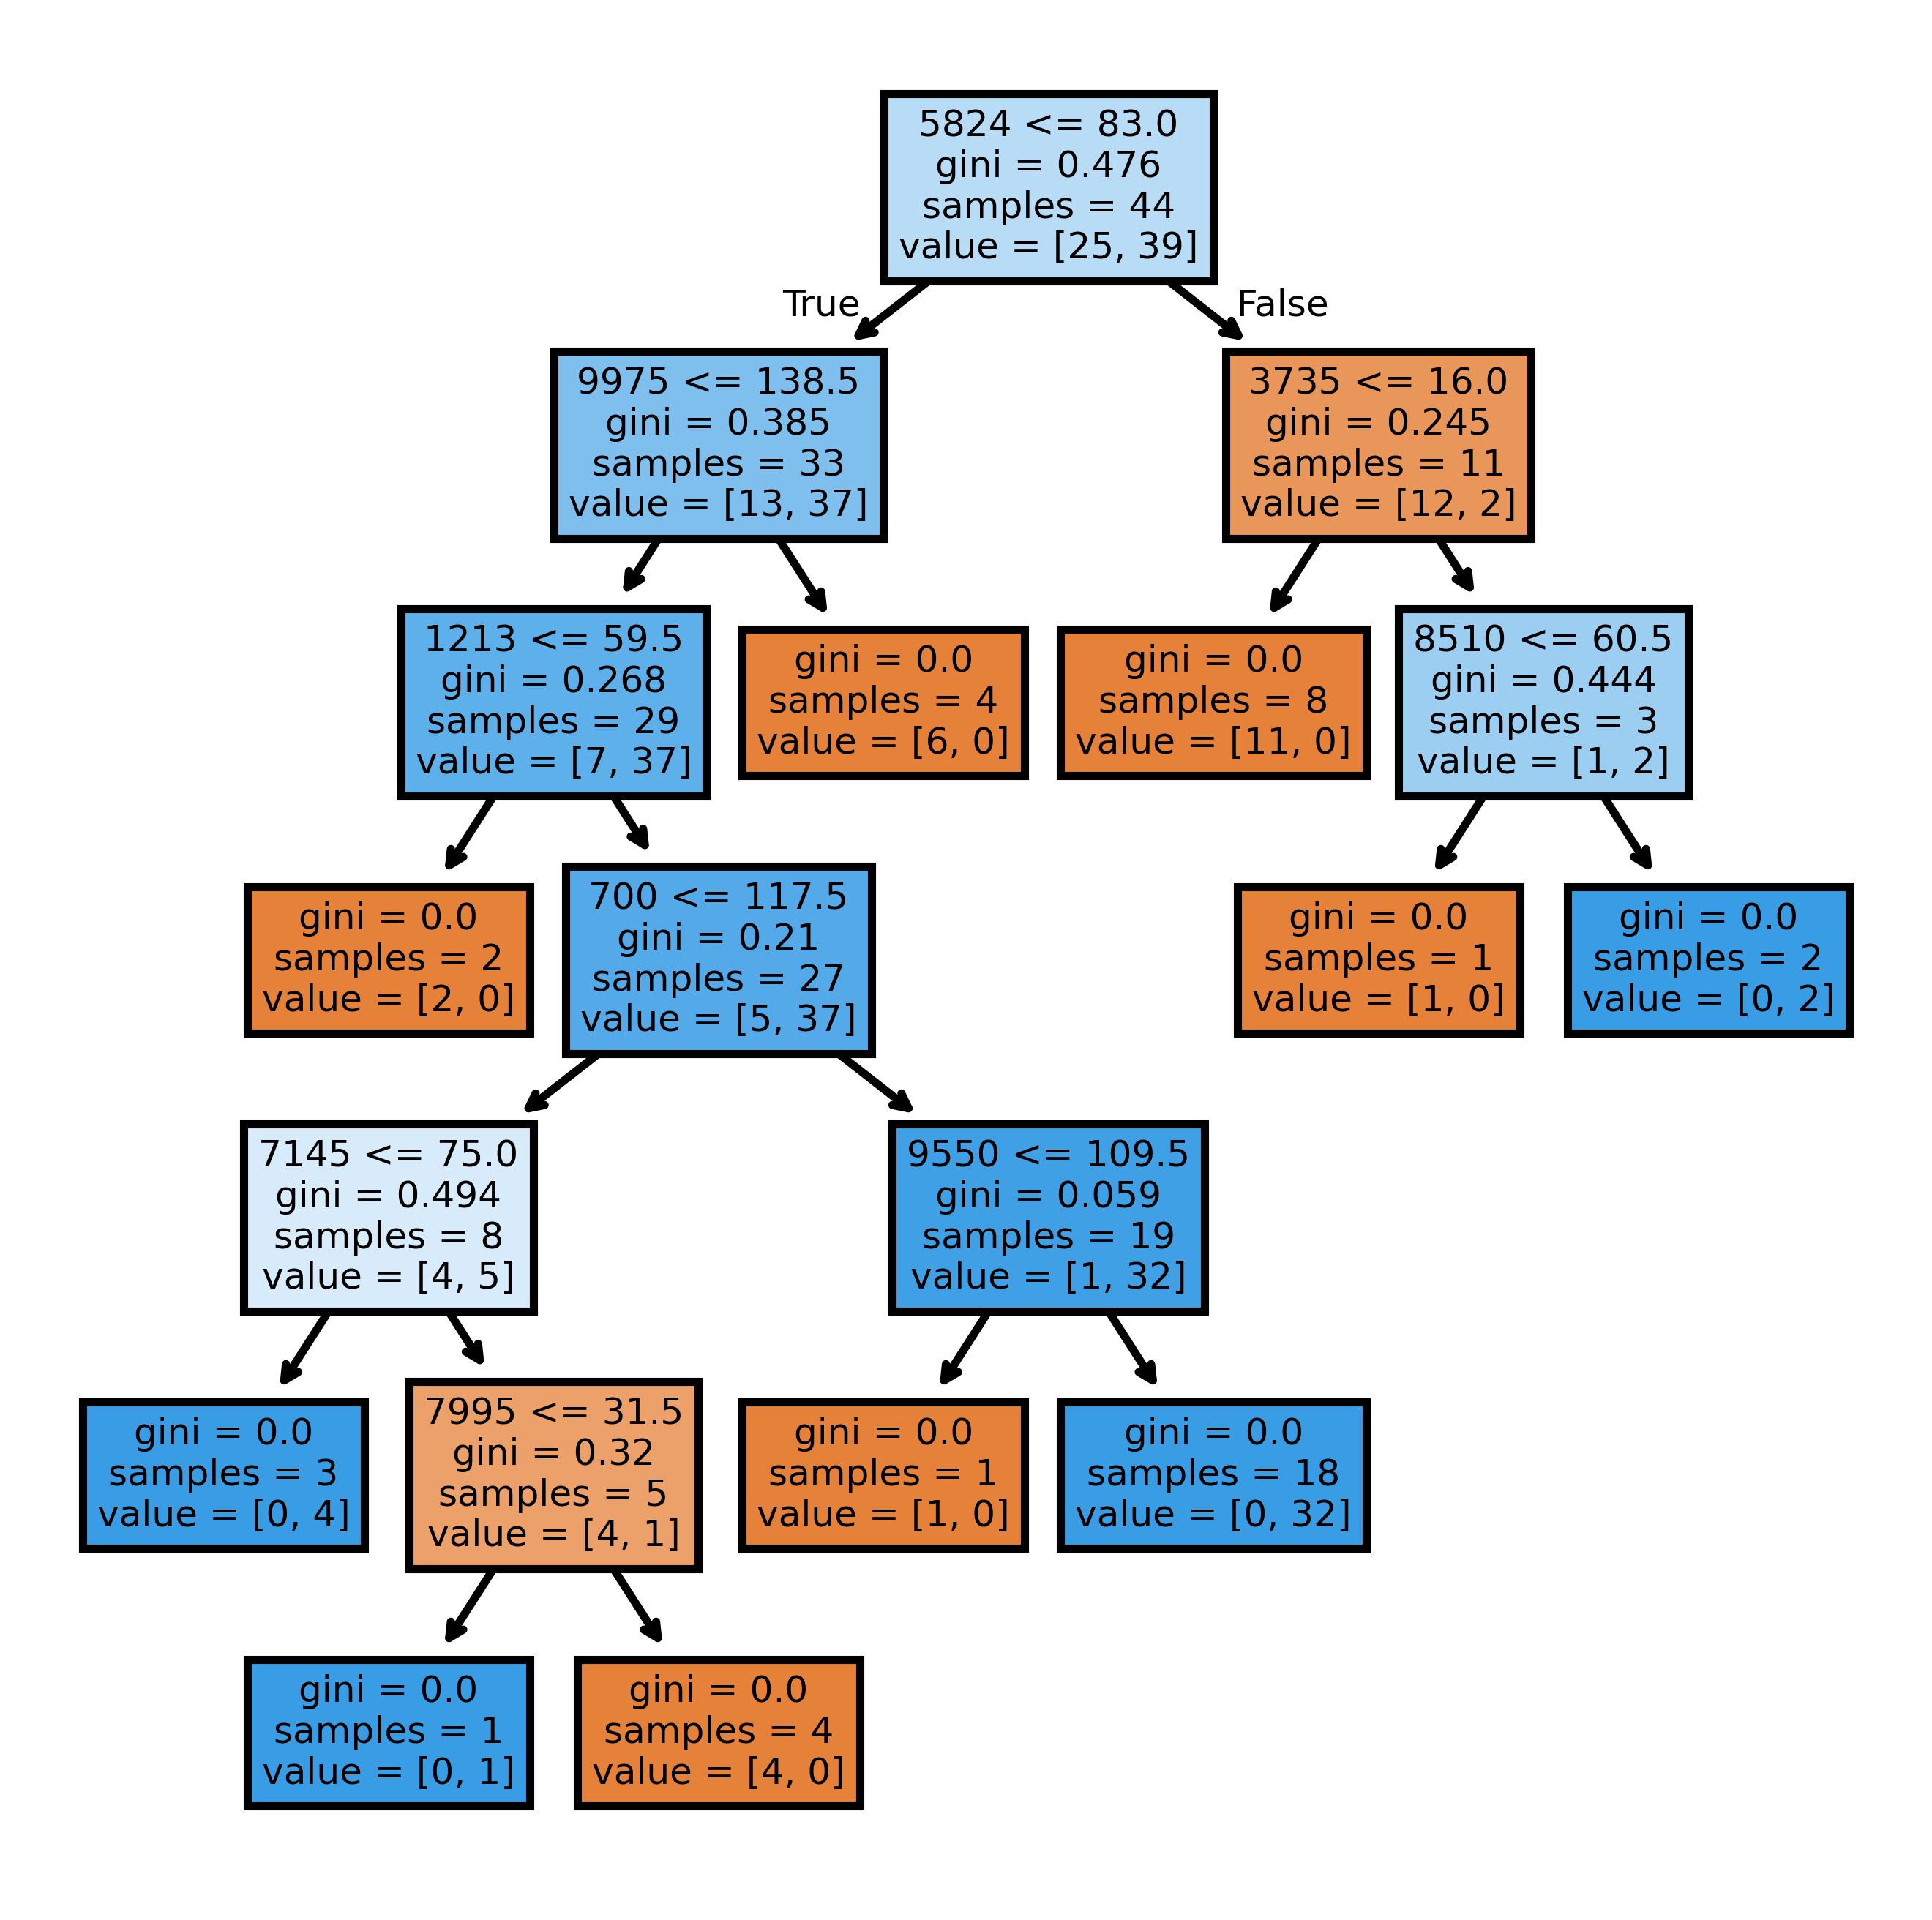

In [65]:
from sklearn import tree

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(clf.estimators_[0],
               feature_names = features.columns, 
               filled = True);



In [48]:
# Try with oversampling minority class (random oversampler)

ros = RandomOverSampler()
X_ro, y_ro = ros.fit_resample(X_train, y_train)
print('Oversampled sample classes:', dict(pd.Series(y_ro).value_counts()))

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    #clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
    clf.fit(X_ro, y_ro)
    print(clf.score(X_test, y_test))

    y_pred = clf.predict(X_test)
    print(classification_report_imbalanced(y_test, y_pred))
    cnf_matrix = pd.crosstab(y_test, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)


Oversampled sample classes: {1: np.int64(48), 0: np.int64(48)}
0.9
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      1.00      0.75      0.92      0.87      0.77        12
          1       1.00      0.75      1.00      0.86      0.87      0.73         8

avg / total       0.91      0.90      0.85      0.90      0.87      0.75        20



Predicted Class,0,1
True Class,,
0,12,0
1,2,6


In [144]:
# SMOTE

smo = SMOTE()
X_sm, y_sm = smo.fit_resample(X_train, y_train)
print('SMOTE sample classes:', dict(pd.Series(y_sm).value_counts()))

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    #clf = RandomForestClassifier(n_jobs=-1, max_depth=20, n_estimators=100, max_features='sqrt', max_leaf_nodes=10)
    clf.fit(X_sm, y_sm)
    print(clf.score(X_test, y_test))

    y_pred = clf.predict(X_test)
    print(classification_report_imbalanced(y_test, y_pred))
    cnf_matrix = pd.crosstab(y_test, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)



SMOTE sample classes: {1: np.int64(48), 0: np.int64(48)}
0.9
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      1.00      0.75      0.92      0.87      0.77        12
          1       1.00      0.75      1.00      0.86      0.87      0.73         8

avg / total       0.91      0.90      0.85      0.90      0.87      0.75        20



Predicted Class,0,1
True Class,,
0,12,0
1,2,6


In [119]:
# Try anomaly detection algos: Isolation Forest

from sklearn import svm
from sklearn.datasets import make_moons, make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, classification_report, make_scorer, recall_score, f1_score

df_train = pd.read_pickle('./train_data_100x100.pkl')
df_train['label'] = 1
df_train.drop('target', axis=1, inplace=True)
df_test = pd.read_pickle('./test_data_100x100.pkl')
df_test['label'] = np.where(df_test['anomaly']=='good', 1, -1)
df_test.drop(['object', 'anomaly'], axis=1, inplace=True)
df_all = pd.concat([df_train, df_test], axis=0)
display(df_all.head())
display(df_all.tail())


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,label
0,21,28,28,28,28,28,28,21,28,28,...,21,21,28,21,21,21,28,21,21,1
1,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,28,21,21,21,1
2,28,21,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,28,1
3,28,28,21,21,21,21,28,21,21,21,...,21,21,21,21,21,21,21,21,21,1
4,21,21,21,28,28,21,21,21,21,21,...,21,21,21,21,21,21,28,21,21,1


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,label
1720,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,-1
1721,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,-1
1722,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,-1
1723,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,-1
1724,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,-1


In [99]:
target = df_all['label']

X_train, X_test, y_train, y_test= train_test_split(df_all, target, test_size=0.2, random_state=42)
X_train = X_train.drop('label', axis = 1)
X_test = X_test.drop('label', axis = 1)


with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    isof = IsolationForest(contamination=0.03, n_estimators=100, n_jobs=-1)
    isof.fit(X_train)
    y_pred = isof.predict(X_test)
    cm = pd.crosstab(y_test, y_pred, rownames=['True classes'], colnames=['Predicted classes'])

print(classification_report(y_test, y_pred))
display(cm)


              precision    recall  f1-score   support

          -1       0.18      0.03      0.06       235
           1       0.78      0.96      0.86       836

    accuracy                           0.75      1071
   macro avg       0.48      0.49      0.46      1071
weighted avg       0.65      0.75      0.68      1071



Predicted classes,-1,1
True classes,,
-1,8,227
1,37,799


In [103]:
# Trying to improve with grid search

skf = StratifiedKFold(n_splits=3) 
folds = list(skf.split(X_train, y_train))
forest = IsolationForest()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    resc = make_scorer(recall_score,pos_label=-1)
    params = {'contamination': np.linspace(0.01, 0.05, 10), 'n_estimators': [100,200,300]}
    search = GridSearchCV(estimator=forest, param_grid=params, scoring=resc, cv=folds, n_jobs=-1)
    
    search.fit(X_train, y_train)
    
    optimal_forest = search.best_estimator_
    y_pred = optimal_forest.predict(X_test)

display(pd.crosstab(y_test, y_pred, rownames=['True classes'], colnames=['Predicted classes']))
print(classification_report(y_test, y_pred))


Predicted classes,-1,1
True classes,,
-1,14,221
1,47,789


              precision    recall  f1-score   support

          -1       0.23      0.06      0.09       235
           1       0.78      0.94      0.85       836

    accuracy                           0.75      1071
   macro avg       0.51      0.50      0.47      1071
weighted avg       0.66      0.75      0.69      1071



In [104]:
# Try anomaly detection algos: One class SVM

from sklearn.preprocessing import MinMaxScaler

# We select only the labels that correspond to 1
y_inliers = y_train[y_train.values==1]

# We create a list of indexes to be able to recover the explanatory variables of these indexes
liste = list(y_inliers.index.values)

# We recover these explanatory variables in a new DataFrame
X_train_inliers = X_train.loc[liste]

scaling = MinMaxScaler(feature_range=(-1, 1)).fit(X_train_inliers)
X_train_inliers = scaling.transform(X_train_inliers)
X_test = scaling.transform(X_test)

clf_osvm = svm.OneClassSVM(kernel='rbf', nu=0.005, gamma='scale')
clf_osvm.fit(X_train_inliers)

y_pred = clf_osvm.predict(X_test)
display(pd.crosstab(y_test, y_pred, rownames=['Real classes'], colnames=['Predicted classes']))
print(classification_report(y_test, y_pred))


Predicted classes,-1,1
Real classes,,
-1,5,230
1,12,824


              precision    recall  f1-score   support

          -1       0.29      0.02      0.04       235
           1       0.78      0.99      0.87       836

    accuracy                           0.77      1071
   macro avg       0.54      0.50      0.46      1071
weighted avg       0.67      0.77      0.69      1071



In [106]:
# Anomaly detection algos on one object type (isolation forest)

df_train = pd.read_pickle('./train_data_100x100.pkl')
df_train = df_train[df_train['target']=='transistor']
df_train['label'] = 1
df_train.drop('target', axis=1, inplace=True)
df_test = pd.read_pickle('./test_data_100x100.pkl')
df_test = df_test[df_test['object']=='transistor']
df_test['label'] = np.where(df_test['anomaly']=='good', 1, -1)
df_test.drop(['object', 'anomaly'], axis=1, inplace=True)
df_all = pd.concat([df_train, df_test], axis=0)
display(df_all.head())
display(df_all.tail())
print(df_all.shape)



,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,label
770,117,119,121,119,101,89,102,115,118,126,...,114,116,114,112,117,114,114,116,111,1
771,105,25,21,21,21,21,21,21,27,67,...,121,116,120,117,116,118,117,118,118,1
772,113,113,115,114,118,110,113,113,119,118,...,116,116,116,115,117,114,117,117,116,1
773,39,28,28,28,23,28,28,21,46,116,...,111,115,112,113,113,114,114,110,112,1
774,113,113,111,115,114,113,116,115,117,117,...,114,117,114,113,114,112,113,115,116,1


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,label
487,120,117,114,104,95,106,117,121,122,126,...,121,121,115,113,119,118,117,120,120,-1
488,123,126,123,124,126,125,127,125,125,126,...,117,92,58,49,92,129,119,116,116,-1
489,112,112,108,109,105,113,118,115,115,117,...,117,112,113,116,117,116,116,113,117,-1
490,121,118,111,109,117,118,119,122,124,127,...,119,122,121,120,123,119,120,120,121,-1
491,115,115,111,110,100,79,91,89,117,122,...,126,117,119,115,119,120,118,122,119,-1


(313, 10001)


In [122]:
target = df_all['label']

X_train, X_test, y_train, y_test= train_test_split(df_all, target, test_size=0.2, random_state=42)
X_train = X_train.drop('label', axis = 1)
X_test = X_test.drop('label', axis = 1)


with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    isof = IsolationForest(contamination=0.03, n_estimators=100, n_jobs=-1)
    isof.fit(X_train)
    y_pred = isof.predict(X_test)
    cm = pd.crosstab(y_test, y_pred, rownames=['True classes'], colnames=['Predicted classes'])

print(classification_report(y_test, y_pred))
display(cm)


              precision    recall  f1-score   support

          -1       0.19      0.03      0.05       235
           1       0.78      0.97      0.86       836

    accuracy                           0.76      1071
   macro avg       0.49      0.50      0.46      1071
weighted avg       0.65      0.76      0.68      1071



Predicted classes,-1,1
True classes,,
-1,7,228
1,29,807


In [123]:
# Trying to improve with grid search

skf = StratifiedKFold(n_splits=3) 
folds = list(skf.split(X_train, y_train))
forest = IsolationForest()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    resc = make_scorer(recall_score,pos_label=-1)
    params = {'contamination': np.linspace(0.01, 0.05, 10), 'n_estimators': [100,200,300]}
    search = GridSearchCV(estimator=forest, param_grid=params, scoring=resc, cv=folds, n_jobs=-1)
    
    search.fit(X_train, y_train)
    
    optimal_forest = search.best_estimator_
    y_pred = optimal_forest.predict(X_test)

display(pd.crosstab(y_test, y_pred, rownames=['True classes'], colnames=['Predicted classes']))
print(classification_report(y_test, y_pred))

Predicted classes,-1,1
True classes,,
-1,12,223
1,51,785


              precision    recall  f1-score   support

          -1       0.19      0.05      0.08       235
           1       0.78      0.94      0.85       836

    accuracy                           0.74      1071
   macro avg       0.48      0.50      0.47      1071
weighted avg       0.65      0.74      0.68      1071



In [121]:
# Try with one class SVM

# We select only the labels that correspond to 1
y_inliers = y_train[y_train.values==1]

# We create a list of indexes to be able to recover the explanatory variables of these indexes
liste = list(y_inliers.index.values)

# We recover these explanatory variables in a new DataFrame
X_train_inliers = X_train.loc[liste]

scaling = MinMaxScaler(feature_range=(-1, 1)).fit(X_train_inliers)
X_train_inliers = scaling.transform(X_train_inliers)
X_test = scaling.transform(X_test)

clf_osvm = svm.OneClassSVM(kernel='rbf', nu=0.005, gamma='scale')
clf_osvm.fit(X_train_inliers)

y_pred = clf_osvm.predict(X_test)
display(pd.crosstab(y_test, y_pred, rownames=['Real classes'], colnames=['Predicted classes']))
print(classification_report(y_test, y_pred))


Predicted classes,-1
Real classes,
-1,5
1,58


              precision    recall  f1-score   support

          -1       0.08      1.00      0.15         5
           1       0.00      0.00      0.00        58

    accuracy                           0.08        63
   macro avg       0.04      0.50      0.07        63
weighted avg       0.01      0.08      0.01        63



/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

(40, 10003)
(40, 10003)
(80, 10003)


,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,label
392,116,111,128,130,135,131,117,120,134,129,...,78,54,41,28,35,55,134,120,112,-1
393,115,113,114,109,119,112,118,119,127,133,...,43,39,39,28,28,28,21,38,113,-1
394,120,64,49,43,43,45,45,39,117,128,...,124,122,124,121,123,119,121,122,125,-1
395,121,120,120,123,117,118,121,122,127,129,...,116,116,116,116,117,116,123,117,117,-1
396,129,126,128,122,118,116,127,130,125,130,...,115,116,113,115,115,113,114,116,116,-1


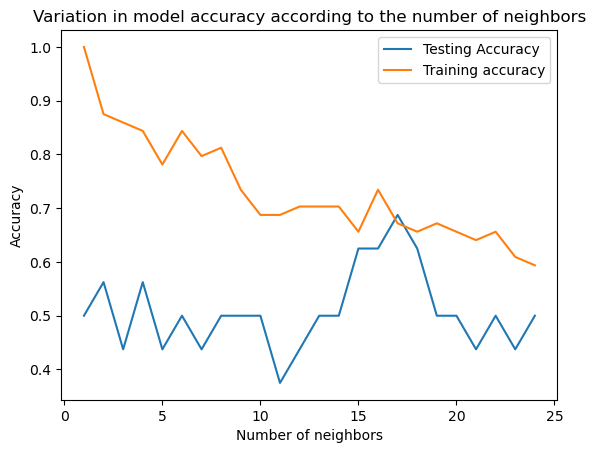

In [136]:
# Try with KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#X_train = StandardScaler().fit_transform(X_train.values.reshape(-1,1))

df_test = pd.read_pickle('./test_data_100x100.pkl')
df_test = df_test[df_test['object']=='transistor']
df_test['label'] = np.where(df_test['anomaly']=='good', 1, -1)
df_test['label'].value_counts()

df_anom = df_test[df_test['label'] == -1]
df_good_eq = df_test[df_test['label'] == 1][:40]
print(df_anom.shape)
print(df_good_eq.shape)
df_eq = pd.concat([df_anom, df_good_eq], axis=0)
print(df_eq.shape)

df_eq.drop(['object', 'anomaly'], axis=1, inplace=True)
display(df_eq.head())

feature_array = df_eq.drop(['label'], axis=1)
label_array = df_eq['label']
X_train, X_test, y_train, y_test = train_test_split(feature_array, label_array, test_size=0.20, shuffle=True, stratify=label_array)

X_train = normalize(X_train)
X_test = normalize(X_test)
neighbours = np.arange(1,25)
train_accuracy = np.empty(len(neighbours))
test_accuracy = np.empty(len(neighbours))

for i,k in enumerate(neighbours):
    knn = KNeighborsClassifier(n_neighbors = k,algorithm="kd_tree",n_jobs=-1)
    warnings.filterwarnings("ignore")
    knn.fit(X_train,y_train.ravel())
    train_accuracy[i] = knn.score(X_train, y_train.ravel())
    test_accuracy[i] = knn.score(X_test, y_test.ravel())
plt.title("Variation in model accuracy according to the number of neighbors")
plt.plot(neighbours, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbours, train_accuracy, label = 'Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()


Text(0.5, 1.0, ' Number of Blobs')

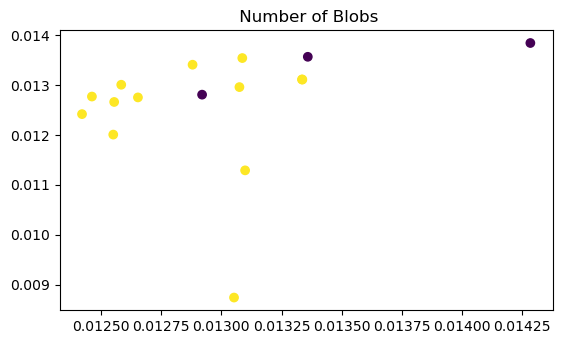

In [137]:
idx = np.where(test_accuracy == max(test_accuracy))
x = neighbours[idx]
knn=KNeighborsClassifier(n_neighbors=x[0],algorithm="kd_tree",n_jobs=-1) #n_jobs=-1 means that all processors are used when searching for means neighbors.
knn.fit(X_train,y_train.ravel())

knn_predicted_test_labels=knn.predict(X_test)

from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
plt.subplot(222)
plt.scatter(X_test[:, 0], X_test[:, 1], c=knn_predicted_test_labels)
plt.title(" Number of Blobs")

In [138]:
knn_accuracy_score  = accuracy_score(y_test,knn_predicted_test_labels)
print("Valeur de l'accuracy:", knn_accuracy_score)

print(classification_report(y_test, knn_predicted_test_labels))

Valeur de l'accuracy: 0.6875
              precision    recall  f1-score   support

          -1       1.00      0.38      0.55         8
           1       0.62      1.00      0.76         8

    accuracy                           0.69        16
   macro avg       0.81      0.69      0.65        16
weighted avg       0.81      0.69      0.65        16

